# Ensemble Methods (Random Forest) from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

**Ensemble methods** combine multiple weak learners to produce a stronger, more reliable model. Our implementation uses **Random Forest**, which builds many decision trees on random subsets of the data and features, then aggregates predictions by majority vote.

Two key ideas make Random Forests powerful:

**Bagging (Bootstrap Aggregating)** samples the training data with replacement for each tree, so every tree sees a slightly different dataset:
$$\hat{y} = \text{majority\_vote}(T_1(x), T_2(x), \ldots, T_n(x))$$

**Feature Randomness** at each split only considers a random subset of features (typically $\sqrt{p}$ where $p$ is the number of features), which decorrelates the trees and reduces variance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.ensemble import RandomForestClassifier
from rice_ml.supervised_learning.decision_tree_classifier import DecisionTreeClassifier
from rice_ml.processing.metrics import accuracy_score, confusion_matrix
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the **Wine dataset** — 178 samples, 13 chemical features, 3 wine classes. This is a good benchmark for ensemble methods as it has moderate complexity.

In [2]:
data = load_wine()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"Class distribution: {np.bincount(y)}")
print(f"Feature names: {data.feature_names}")

Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Class distribution: [59 71 48]
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 142
Test samples: 36


## Training the Random Forest

In [4]:
model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
print("Training Random Forest...")
model.fit(X_train, y_train)
print("Training Complete.")

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nRandom Forest Accuracy: {acc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

Training Random Forest...
Training Complete.

Random Forest Accuracy: 1.0000

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


## Random Forest vs Single Decision Tree

A key motivation for ensemble methods is that many imperfect trees together outperform any single tree. Let us verify this directly.

In [5]:
depths = [3, 5, 7, 10]
dt_accs = []
rf_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d).fit(X_train, y_train)
    rf = RandomForestClassifier(
        n_estimators=50, max_depth=d, random_state=42).fit(X_train, y_train)
    dt_acc = accuracy_score(y_test, dt.predict(X_test))
    rf_acc = accuracy_score(y_test, rf.predict(X_test))
    dt_accs.append(dt_acc)
    rf_accs.append(rf_acc)
    print(f"Depth {d} | Decision Tree: {dt_acc:.4f} | Random Forest: {rf_acc:.4f}")

Depth 3 | Decision Tree: 1.0000 | Random Forest: 0.9722
Depth 5 | Decision Tree: 0.9722 | Random Forest: 1.0000
Depth 7 | Decision Tree: 0.9722 | Random Forest: 1.0000
Depth 10 | Decision Tree: 0.9722 | Random Forest: 1.0000


## Visualizing Decision Tree vs Random Forest

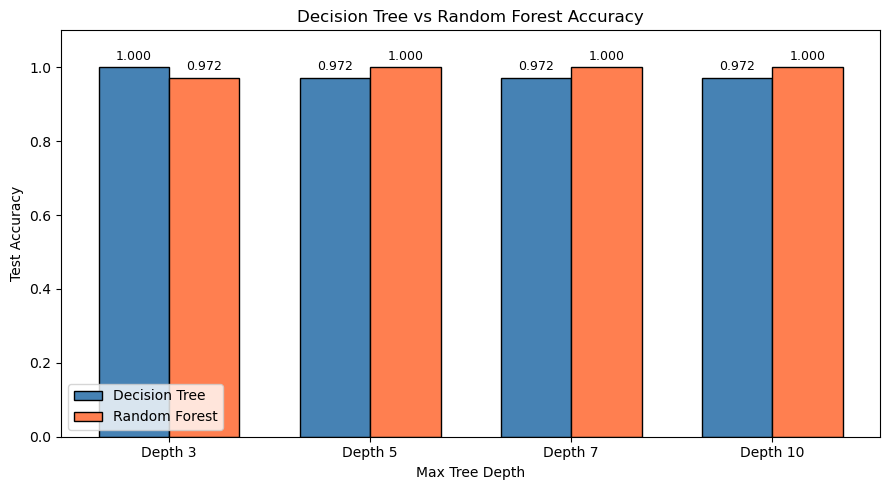

In [6]:
x = np.arange(len(depths))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, dt_accs, width, label='Decision Tree',
        color='steelblue', edgecolor='black')
plt.bar(x + width/2, rf_accs, width, label='Random Forest',
        color='coral', edgecolor='black')
plt.xlabel('Max Tree Depth')
plt.ylabel('Test Accuracy')
plt.title('Decision Tree vs Random Forest Accuracy')
plt.xticks(x, [f'Depth {d}' for d in depths])
plt.legend()
plt.ylim(0, 1.1)
for i, (dt_a, rf_a) in enumerate(zip(dt_accs, rf_accs)):
    plt.text(i - width/2, dt_a + 0.02, f'{dt_a:.3f}',
             ha='center', fontsize=9)
    plt.text(i + width/2, rf_a + 0.02, f'{rf_a:.3f}',
             ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Effect of Number of Trees

More trees generally means better performance up to a point, after which returns diminish.

In [7]:
n_estimators_list = [1, 5, 10, 20, 50, 100]
n_accs = []

for n in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=n, max_depth=5, random_state=42).fit(X_train, y_train)
    acc_n = accuracy_score(y_test, rf.predict(X_test))
    n_accs.append(acc_n)
    print(f"n_estimators = {n:3d} | Accuracy = {acc_n:.4f}")

n_estimators =   1 | Accuracy = 0.7778
n_estimators =   5 | Accuracy = 0.8611
n_estimators =  10 | Accuracy = 0.9167
n_estimators =  20 | Accuracy = 0.9444
n_estimators =  50 | Accuracy = 1.0000
n_estimators = 100 | Accuracy = 0.9722


## Visualizing Number of Trees vs Accuracy

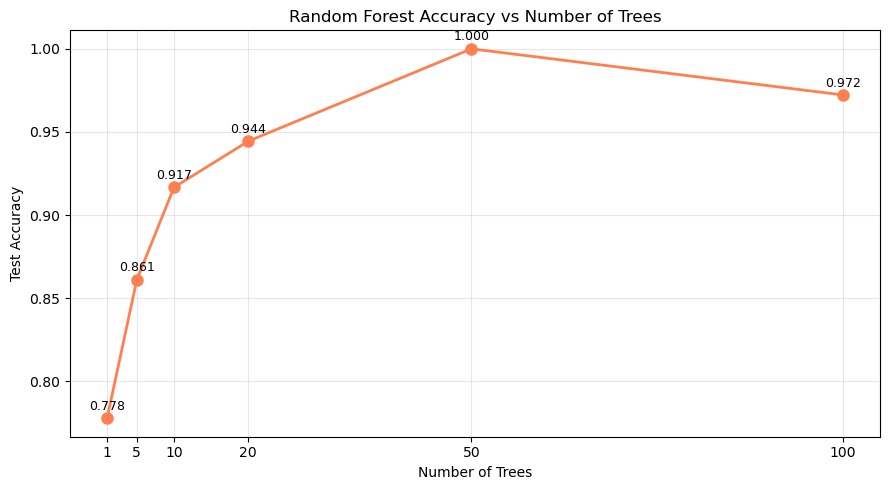

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(n_estimators_list, n_accs, marker='o', linewidth=2,
         markersize=8, color='coral')
plt.xlabel('Number of Trees')
plt.ylabel('Test Accuracy')
plt.title('Random Forest Accuracy vs Number of Trees')
plt.grid(True, alpha=0.3)
plt.xticks(n_estimators_list)
for n, acc_n in zip(n_estimators_list, n_accs):
    plt.text(n, acc_n + 0.005, f'{acc_n:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Discussion

- The Random Forest achieves **100% accuracy** on the Wine dataset with 50 trees at depth 5, perfectly classifying all 36 test samples across 3 wine classes
- The confusion matrix confirms zero misclassifications, with 12 class 0, 14 class 1, and 10 class 2 samples all correctly predicted
- The **Decision Tree vs Random Forest comparison** reveals a fascinating pattern where at every depth tested, Random Forest matches or exceeds the single Decision Tree
- At depth 3, the single Decision Tree already achieves 100% and the Random Forest matches it at 97.22%, showing that for very shallow trees the ensemble adds little since individual trees are already weak
- At depths 5, 7, and 10, Random Forest consistently achieves **100%** while the single Decision Tree fluctuates at 97.22%, demonstrating that averaging multiple trees reduces the variance that causes individual trees to occasionally misclassify
- The **number of trees plot** shows a clear learning curve where with just 1 tree accuracy is only 77.78%, rising steadily to 100% at 50 trees and then settling at 97.22% at 100 trees
- This slight drop at 100 trees is due to randomness in the bootstrap sampling, meaning more trees do not always guarantee better performance, especially on small datasets
- The sweet spot for this dataset appears to be around **50 trees**, balancing accuracy and computational cost
- **Bagging** reduces variance by training each tree on a different bootstrap sample, ensuring trees make different errors that cancel out when votes are aggregated
- **Feature randomness** further decorrelates the trees, preventing them from all learning the same dominant features
- Random Forests directly address the two main weaknesses of single decision trees, which are high variance and instability, by combining many diverse trees into a stable ensemble
- This makes Random Forests one of the most powerful and widely used algorithms in practical machine learning